# Methodology v.01 — end-to-end notebook

Pipeline walkthrough for *Methodology v.01* using `water_methodology_impl.py` (see the module **Compliance audit** for equation alignment). **Table 4 P5** includes rolling min/max (and mean/std) at 1h and 6h.

1. **Dataset curation & action reconstruction** — **Table 2** via `water_rdi_loaders.build_table2_mixed`: **USGS NWIS** IV/DV for DS-1 / DS-4 / DS-5 when reachable; **bundled WQP-derived DS-2 and DS-3** (`WATER_DS2_CSV` / `WATER_DS3_CSV` override bundled paths when set). **CUSUM** (Eq. 3) + **inverse titration** (Eq. 4); **Table 3** via `table3_reconstruction_metrics`.
2. **Physics-grounded environment** — `f_titration` (Sec 2.3); **LSTM surrogate** (Table 5); **Stage 2a** — Sec 2.3.2 + **Table 6** gates before PPO.
3. **MDP** — 13-D observation (Table 8), 11 actions (Table 9), five-term reward (Table 10), γ=0.99, T_max=480 (Sec 4.5).
4. **PPO** (Table 12) — GAE-λ, clipped objective, entropy schedule, curriculum masking (Sec 5.3), MC-Dropout gate (Table 13), hybrid physics→LSTM (Eq. 5).
5. **Evaluation** — Tier-1 DCR + **Wilcoxon** vs **RBT, PID, LUT** (Sec 7.2–7.3; Bonferroni α/3).
6. **OOD & sim-to-real** — **DS-4** shift under train scalers (Q2); **DS-5** in Stage 2a + Table 4 P4; **Stage 7** runs `methodology_first_pass_small` for a consolidated smoke pass.

> **Data:** `WATER_USE_SYNTH_ONLY=1` forces synthetic Table-2 proxies. The default path uses public NWIS, bundled WQP CSVs under `data/rdi/`, and **DS-5** from KU-MWQ when `WATER_DS5_SOURCE=auto` and the workbook is on disk. Chronological splits; train-only scalers (Table 4 P6).
> **Compute:** `DEMO_MODE=True` shortens LSTM/PPO budgets; `DEMO_MODE=False` matches Table-12-scale runs.
> **Figures:** Stages 1–6 write 300 dpi PNGs to `figures_paper/`. Interpretation: `Results_Analysis_Figures.md`.


In [1]:
import os, sys
from pathlib import Path

# Repo root on sys.path
ROOT = Path.cwd()
if (ROOT / "water_methodology_impl.py").is_file():
    sys.path.insert(0, str(ROOT))
elif (ROOT.parent / "Water" / "water_methodology_impl.py").is_file():
    sys.path.insert(0, str(ROOT.parent / "Water"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import water_methodology_impl as m
print("Loaded water_methodology_impl from:", m.__file__)
print("\nTable 2 — RDI dataset inventory (*Methodology v.01* names):")
for line in m.rdi_table2_lines():
    print(" ", line)


Loaded water_methodology_impl from: /home/situser1/Water/water_methodology_impl.py

Table 2 — RDI dataset inventory (*Methodology v.01* names):
  DS-1 — Large-Scale WQ Monitoring (National): Primary surrogate training data; dosing event reconstruction source
  DS-2 — Regional Industrial Surface & Groundwater: Regulatory constraint calibration; buffering capacity parameter estimation
  DS-3 — Survey-Based Industrial Effluent Reports: Discharge standard threshold validation; compliance label ground-truth
  DS-4 — Global Multi-Decadal WQ (GEMS/Water–UN): Out-of-distribution (OOD) generalization test set, never seen in training
  DS-5 — IoT Sensor-Based WQ (1 Hz real-time): (a) Noise model fitting; (b) Sim-to-real validation, held-out real trajectories


## Reproducibility & figure export

RNG seeds (Python, NumPy, PyTorch) and Matplotlib defaults. **Figures** save under `figures_paper/` at 300 dpi.

Stage 2a uses the Table-2 **DS-5** stream (KU-MWQ or NWIS), tiled to the length required for Sec 2.3.2.

**After you change `water_*.py` or pull from git**, use **Kernel → Restart Kernel** (or “Restart and Run All”). Otherwise Jupyter keeps **old imports in memory** and printed metrics (LSTM, Table 6, Sec 2.3.2 MAPE) won’t match the files on disk.


In [2]:
import random
import torch

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

from pathlib import Path
import paper_figures as pf

FIG_DIR = Path("figures_paper")
FIG_DIR.mkdir(parents=True, exist_ok=True)
pf.configure_matplotlib()
print("Publication: RNG seeds fixed | figures ->", FIG_DIR.resolve())


Publication: RNG seeds fixed | figures -> /home/situser1/Water/figures_paper


## Stage 1 — Table 2 inventory + CUSUM reconstruction (Sec 2.1–2.4)

`build_table2_mixed` loads Table 2 frames, then Eq. 3–4 labelling and **Table 3** diagnostics (event rate, non-null fraction).


In [3]:
import os

DEMO_MODE = True  # False = Table-12-scale LSTM/PPO budgets

os.environ["WATER_TABLE2_REQUIRE_REAL"] = "1"  # require public/bundled Table-2 data

from water_rdi_loaders import build_table2_mixed

frames, TABLE2_FLAGS = build_table2_mixed(demo_mode=DEMO_MODE, synth_module=m)
ds1, ds2, ds3, ds4 = frames["DS-1"], frames["DS-2"], frames["DS-3"], frames["DS-4"]
DS5_IV = frames["DS-5"]
print("Table 2 — public/real where True:", TABLE2_FLAGS)

print(m.rdi_dataset_name("DS-3"), "— compliance positive fraction:", float(ds3["compliance_status"].mean()))
A_T, C_T = m.estimate_AT_CT_from_ds2(ds2, float(ds1["conductivity_uScm"].median()))
acts = m.reconstruct_actions(ds1, A_T, C_T)

print("A_T, C_T (buffering proxies):", A_T, C_T)
print("CUSUM / inverse: non-null action frac =", float((acts != 0).mean()))
ph = ds1["pH"].to_numpy()
print("CUSUM event rate =", float(m.cusum_events(ph).mean()))

t3 = m.table3_reconstruction_metrics(ds1, A_T, C_T)
print("Table 3 (reconstruction diagnostics):", t3)

# Paper figures — Table 2 data overview (DS-1 / DS-5 / DS-4)
from pathlib import Path

import paper_figures as pf

_out = Path("figures_paper")
_out.mkdir(parents=True, exist_ok=True)
pf.plot_table2_overview(ds1, DS5_IV, ds4, TABLE2_FLAGS, _out)
print(
    "Saved: fig_ds1_ph_timeseries.png, fig_ds5_sensors.png, fig_ds4_monthly_ph.png ->",
    _out.resolve(),
)


Table 2 — public/real where True: {'DS-1': True, 'DS-2': True, 'DS-3': True, 'DS-4': True, 'DS-5': True}
Survey-Based Industrial Effluent Reports — compliance positive fraction: 0.854125
A_T, C_T (buffering proxies): 1.2658695 0.5
CUSUM / inverse: non-null action frac = 0.0
CUSUM event rate = 0.0
Table 3 (reconstruction diagnostics): {'n_timesteps': 5750.0, 'n_cusum_windows': 0.0, 'discard_rate': 0.0, 'null_action_fraction': 1.0, 'inverse_residual_mae': nan, 'cusum_flag_timestep_rate': 0.0, 'cusum_fp_proxy_flat_noise': 0.0}
Saved: fig_ds1_ph_timeseries.png, fig_ds5_sensors.png, fig_ds4_monthly_ph.png -> /home/situser1/Water/figures_paper


## Stage 1d — Preprocessing P1–P6 (Table 4)

Chronological 70/15/15; **MinMax** fit on train only; DS-4 kept out of training in `run_full_pipeline`.


In [4]:
sl_tr, sl_va, sl_te = m.chronological_split(len(ds1))
tr_raw, va_raw, te_raw = ds1.iloc[sl_tr], ds1.iloc[sl_va], ds1.iloc[sl_te]
tr_f, st = m.preprocess_monitor(tr_raw, fit=True)
va_f, _ = m.preprocess_monitor(va_raw, stats=st, fit=False)
tr_f = m.attach_actions(tr_f, acts[sl_tr])
va_f = m.attach_actions(va_f, acts[sl_va])
print(tr_f.head(3))


            timestamp   pH_phys    pH_raw       dPH        d1        d2  \
0 2026-02-17 02:45:00  6.900000  0.500000  0.500000  0.500000  0.500000   
1 2026-02-17 03:00:00  6.900000  0.500000  0.500000  0.500000  0.500000   
2 2026-02-17 03:15:00  6.866667  0.458333  0.458333  0.333333  0.416667   

    ph_rm1h       ph_rs1h      cond        DO  ...   ph_mn1h  ph_mx1h  \
0  0.500000  0.000000e+00  0.880952  0.968553  ...  0.500000      0.5   
1  0.500000  1.538370e-14  0.873016  0.968553  ...  0.500000      0.5   
2  0.486111  3.333333e-01  0.857143  0.968553  ...  0.458333      0.5   

    ph_mn6h   ph_mx6h  cond_mn1h  cond_mx1h  cond_mn6h  cond_mx6h  a  a_prev  
0  0.500000  0.454545   0.880952   0.880952   0.902439      0.875  0     0.0  
1  0.500000  0.454545   0.873016   0.880952   0.894309      0.875  0     0.0  
2  0.458333  0.454545   0.857143   0.880952   0.878049      0.875  0     0.0  

[3 rows x 31 columns]


## Stage 2 — LSTM surrogate (Table 5)

**Architecture:** 2×LSTM (256→128), dropout p=0.2, L=48, Huber δ=1, Adam 1e⁻³ + cosine schedule. Validation RMSE is in **physical pH** (`pH + ΔpH`).


In [5]:
import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mm_cols = st["mm_cols"]
tr_ds = m.SeqDS(tr_f, mm_cols, m.L_SEQ)
va_ds = m.SeqDS(va_f, mm_cols, m.L_SEQ)
lstm, dph_scaler, sigma_model = m.train_lstm(
    tr_ds,
    va_ds,
    DEVICE,
    m.L_SEQ,
    epochs=25 if DEMO_MODE else m.LSTM_EPOCHS,
    patience=4 if DEMO_MODE else m.LSTM_PATIENCE,
)
print("LSTM OK on", DEVICE, "| σ_model (ΔpH RMSE) =", sigma_model)


LSTM OK on cuda | σ_model (ΔpH RMSE) = 0.015589298203192064


## Stage 2a — Pre-RL gates (Sec 2.3.2, Table 6)

Sec 2.3.2 one-step error on DS-5; LSTM validation RMSE and MAE(ΔpH) on the val split; **Table 6** pass/fail via `water_experiments_small`; `lstm_ds5_step_metrics` on DS-5 with train-fitted scalers.

`MAPE_pct` uses a **symmetric denominator** and a **per-step cap** so it stays interpretable when observed ΔpH is near zero; **`median_abs_dph_err`** is the primary gate statistic for Sec 2.3.2.


In [6]:
import water_experiments_small as ex
from paper_figures import extend_ds5_to_length

# DS-5 gate stream: real Table-2 data tiled to required length
if TABLE2_FLAGS.get("DS-5") and len(DS5_IV) >= 200 and "pH" in DS5_IV.columns:
    ds5_hz_gate = extend_ds5_to_length(DS5_IV, 100_000 if DEMO_MODE else 150_000)
else:
    ds5_hz_gate = m.synth_ds5_hz(100_000 if DEMO_MODE else 150_000)
sec232 = ex.validate_simulator_sec232(
    ds5_hz_gate, A_T, C_T, n_steps=80 if DEMO_MODE else 200
)
lstm_gate = ex.lstm_val_rmse_and_ece(
    lstm, va_ds, dph_scaler, DEVICE, max_batches=24 if DEMO_MODE else 48
)
gates = ex.table6_gates(
    lstm_gate["surrogate_val_RMSE_pH"],
    lstm_gate["surrogate_MAE_dph_residual"],
    sec232["median_abs_dph_err"],
)
print("Sec 2.3.2 (simulator vs DS-5 Hz drift, random one-step actions):", sec232)
print("LSTM val metrics (subset of Table 6):", lstm_gate)
print("Table 6 gates (Methodology v.01 thresholds):", gates)

ds5_15m_eval = m.ds5_downsample_15m(ds5_hz_gate)
ds5_lstm = ex.lstm_ds5_step_metrics(
    ds5_15m_eval,
    st,
    lstm,
    dph_scaler,
    mm_cols,
    A_T,
    C_T,
    DEVICE,
    max_batches=16 if DEMO_MODE else 40,
)
print("LSTM on DS-5 (15m, train scalers, Table 6 gate-4 proxy):", ds5_lstm)


Sec 2.3.2 (simulator vs DS-5 Hz drift, random one-step actions): {'MAPE_pct': 88.69296059866576, 'MAPE_pct_median': 100.0, 'median_abs_dph_err': 0.07732879170625484, 'n': 80.0}
LSTM val metrics (subset of Table 6): {'surrogate_val_RMSE_pH': 0.015726209628388266, 'surrogate_MAE_dph_residual': 0.00602950025005767, 'n_residuals': 814.0}
Table 6 gates (Methodology v.01 thresholds): {'gate_RMSE_pass': True, 'gate_MAE_dph_pass': True, 'gate_sec232_median_dph_pass': True, 'thresholds': {'rmse_max': 0.1, 'mae_dph_max': 0.07, 'median_dph_err_max': 0.25}}
LSTM on DS-5 (15m, train scalers, Table 6 gate-4 proxy): {'median_abs_dph_err': 0.05036475509405136, 'rmse_dph': 0.0629935079446479, 'n': 622.0}


## Stage 2b — MC-Dropout variance calibration (Table 13)

95th percentile of training predictive variance becomes the **uncertainty gate** threshold during RL.


In [7]:
from torch.utils.data import DataLoader

loader = DataLoader(tr_ds, batch_size=64, shuffle=True)
vars_train = []
for k, (xb, _, _) in enumerate(loader):
    if k > 12:
        break
    v = m.mc_predictive_variance(lstm, xb.to(DEVICE), 8 if DEMO_MODE else 20, DEVICE)
    if np.isfinite(v):
        vars_train.append(v)
vars_ok = [v for v in vars_train if np.isfinite(v)]
unc_p95 = float(np.percentile(vars_ok, 95)) if vars_ok else float("nan")
print("uncertainty p95 =", unc_p95)


uncertainty p95 = 0.0031234248541295523


## Stage 3–5 — Hybrid MDP + PPO (Eq. 5–6, Tables 10–13)

`WastewaterMDP` switches from **physics** to **LSTM** after `PHYSICS_WARMSTART_STEPS`; applies **curriculum masking** on actions {4,5,9,10}; **MC-Dropout** penalty when variance > p95.


In [8]:
phys_warm = 6_000 if DEMO_MODE else 100_000
curr_steps = 5_000 if DEMO_MODE else 200_000
total_steps = 12_000 if DEMO_MODE else 5_000_000
rollout = 512 if DEMO_MODE else 2048
minib = 128 if DEMO_MODE else 512

# σ from Table-2 DS-5 (KU-MWQ / NWIS); synthetic fallback if DS-5 unavailable
if TABLE2_FLAGS.get("DS-5") and len(DS5_IV) >= 200 and "pH" in DS5_IV.columns:
    ds5_hz = DS5_IV
else:
    ds5_hz = m.synth_ds5_hz(3600 if DEMO_MODE else 7200)
sigma_ph, sigma_cond = m.estimate_sigmas_from_ds5(ds5_hz)


def make_env():
    return m.WastewaterMDP(
        lstm,
        A_T,
        C_T,
        DEVICE,
        physics_warm=phys_warm,
        curriculum_steps=curr_steps,
        unc_p95=unc_p95,
        mc_T=8 if DEMO_MODE else 30,
        mm=st["mm"],
        mm_cols=mm_cols,
        dph_scaler=dph_scaler,
        sigma_ph=sigma_ph,
        sigma_model=sigma_model,
        sigma_cond=sigma_cond,
    )

policy = m.ppo_train(
    make_env,
    total_steps=total_steps,
    rollout_len=rollout,
    minibatch=minib,
    device=DEVICE,
    warmup=1500 if DEMO_MODE else 10_000,
    physics_warm=phys_warm,
    curriculum_steps=curr_steps,
    seed=42,
    ent_decay_steps=15_000 if DEMO_MODE else m.ENT_DECAY_STEPS,
)
print("PPO training finished.")


PPO training finished.


## Stage 5 — Tier-1 evaluation + Wilcoxon (Sec 7.2–7.3, Table 16)

**DCR** on 480-step episodes; pairwise **Wilcoxon** vs RBT, PID, and LUT (Bonferroni α/3).


PPO DCR mean: 13.210323119639428 RBT: 91.63201663201664 PID: 98.44074844074844 LUT: 99.49757449757449
Wilcoxon PPO vs RBT (Bonferroni α/3): stat=0.0, p=0.00048828125
Wilcoxon PPO vs PID (Bonferroni α/3): stat=0.0, p=0.00048828125
Wilcoxon PPO vs LUT (Bonferroni α/3): stat=0.0, p=0.00048828125


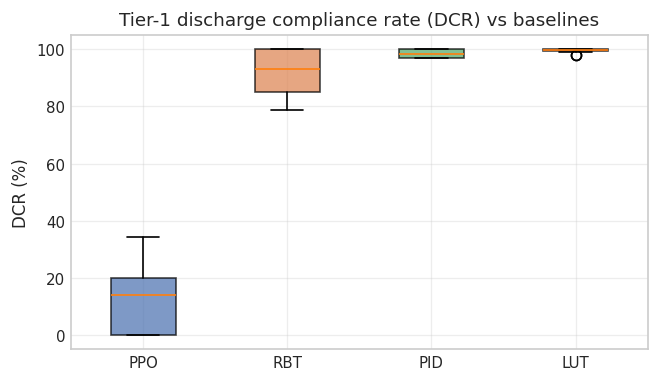

In [9]:
import water_experiments_small as ex

n_ep = 12 if DEMO_MODE else 80
ppo_dcrs = [m.rollout_policy(policy, make_env(), np.random.default_rng(i), 1, DEVICE)["DCR"] for i in range(n_ep)]


def _episode_dcr(ctrl: str, seed: int) -> float:
    env = make_env()
    rng = np.random.default_rng(seed)
    env.reset(rng)
    phs = [env.ph]
    pidc = m.PIDController() if ctrl == "pid" else None
    for _ in range(m.T_MAX):
        if ctrl == "rbt":
            a = m.rule_based_action(env.ph)
        elif ctrl == "pid":
            a = pidc.action(env.ph)
        elif ctrl == "lut":
            a = ex.lut_greedy_action(env.ph, env.A_T, env.C_T)
        else:
            a = 0
        _, _, done, _ = env.step(a, rng)
        phs.append(env.ph)
        if done:
            break
    ph_arr = np.asarray(phs)
    return float(np.mean((ph_arr >= m.PH_LO) & (ph_arr <= m.PH_HI)) * 100.0)


rbt_dcrs = np.asarray([_episode_dcr("rbt", i) for i in range(n_ep)])
pid_dcrs = np.asarray([_episode_dcr("pid", i + 10_000) for i in range(n_ep)])
lut_dcrs = np.asarray([_episode_dcr("lut", i + 20_000) for i in range(n_ep)])
ppo_dcrs = np.asarray(ppo_dcrs)

alpha_b = 0.05 / 3.0
print("PPO DCR mean:", float(np.mean(ppo_dcrs)), "RBT:", float(np.mean(rbt_dcrs)), "PID:", float(np.mean(pid_dcrs)), "LUT:", float(np.mean(lut_dcrs)))
for name, other in [("RBT", rbt_dcrs), ("PID", pid_dcrs), ("LUT", lut_dcrs)]:
    stat, p = m.wilcoxon_report(ppo_dcrs, other, alpha_b)
    print(f"Wilcoxon PPO vs {name} (Bonferroni α/3): stat={stat}, p={p}")

import paper_figures as pf
from pathlib import Path

_fd = Path("figures_paper")
_fd.mkdir(parents=True, exist_ok=True)
fig = pf.plot_dcr_boxplot(
    ppo_dcrs,
    rbt_dcrs,
    pid_dcrs,
    lut_dcrs,
    _fd,
    title="Tier-1 discharge compliance rate (DCR) vs baselines",
    close=False,
)
plt.show()
plt.close(fig)


## Stage 6 — OOD diagnostics (Q2) and sim-to-real (Q3)

**Q2 (Sec 7.1, DS-4):** Stage-1 **DS-4** (monthly NWIS DV when `TABLE2_FLAGS['DS-4']`) passes through the **train-fitted** preprocessor with `fit=False` to quantify mean shift in normalized features vs DS-1 train.

**Q3 (DS-5):** Sec 2.3.2 and Stage 5 use the Table-2 DS-5 stream; Stage 7 aggregates extended smoke metrics via `methodology_first_pass_small`.


In [10]:
from pathlib import Path

import paper_figures as pf

print(m.rdi_dataset_name("DS-4"), "| NWIS monthly (real):", TABLE2_FLAGS.get("DS-4"))
ds4_full = ds4.copy()
ds4_full["DO_mgL"] = 6.0
ds4_full["turbidity_NTU"] = 12.0
ds4_full["temperature_C"] = 20.0
ds4_f, _ = m.preprocess_monitor(ds4_full, stats=st, fit=False)
cols = [c for c in mm_cols if c in tr_f.columns and c in ds4_f.columns]
if cols:
    shift = {c: float(ds4_f[c].mean() - tr_f[c].mean()) for c in cols[:8]}
    print("OOD mean shift (DS-4 − train), first features:", shift)
    pf.plot_ood_shift_bars(shift, Path("figures_paper"))
    print("Saved: fig_ood_feature_shift.png")
else:
    print("OOD shift: no overlapping monitor columns (DS-4 vs train).")


Global Multi-Decadal WQ (GEMS/Water–UN) | NWIS monthly (real): True
OOD mean shift (DS-4 − train), first features: {'pH_raw': 1.6883330414101738, 'dPH': 1.6883330414101736, 'd1': -0.03049324534719361, 'd2': -0.0030120481927710108, 'ph_rm1h': 1.695627305028597, 'ph_rs1h': 2.4335089881651624, 'cond': 4.442733343437176, 'DO': -0.8198497693086764}
Saved: fig_ood_feature_shift.png


## Stage 7 — Consolidated smoke (`methodology_first_pass_small`)

Runs `run_full_pipeline`-equivalent stages with Sec 2.3.2, Table 6-style gates, tier metrics, LUT + DDPG baselines, and Bonferroni-corrected paired tests vs PPO.


In [11]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if (ROOT / "water_experiments_small.py").is_file():
    sys.path.insert(0, str(ROOT))
elif (ROOT.parent / "Water" / "water_experiments_small.py").is_file():
    sys.path.insert(0, str(ROOT.parent / "Water"))

import water_experiments_small as ex

rep = ex.methodology_first_pass_small(demo_mode=True)
print("Sec 2.3.2:", rep["sec232"])
print("LSTM val metrics:", rep["lstm_metrics"])
print("Table 6 gates:", rep["table6_gates"])
print("Tier1 DCR keys:", list(rep["tier1"].keys()))


Sec 2.3.2: {'MAPE_pct': 88.69296059866576, 'MAPE_pct_median': 100.0, 'median_abs_dph_err': 0.07732879170625484, 'n': 80.0}
LSTM val metrics: {'surrogate_val_RMSE_pH': 0.01578913677511955, 'surrogate_MAE_dph_residual': 0.004817381507908551, 'n_residuals': 814.0}
Table 6 gates: {'gate_RMSE_pass': True, 'gate_MAE_dph_pass': True, 'gate_sec232_median_dph_pass': True, 'thresholds': {'rmse_max': 0.1, 'mae_dph_max': 0.07, 'median_dph_err_max': 0.25}}
Tier1 DCR keys: ['ppo_DCR', 'rbt_DCR', 'pid_DCR', 'lut_DCR', 'ddpg_DCR']
